In [103]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [104]:
df = sns.load_dataset('titanic')

In [105]:
df.head(3)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True


In [106]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [107]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [108]:
df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

<Axes: xlabel='fare'>

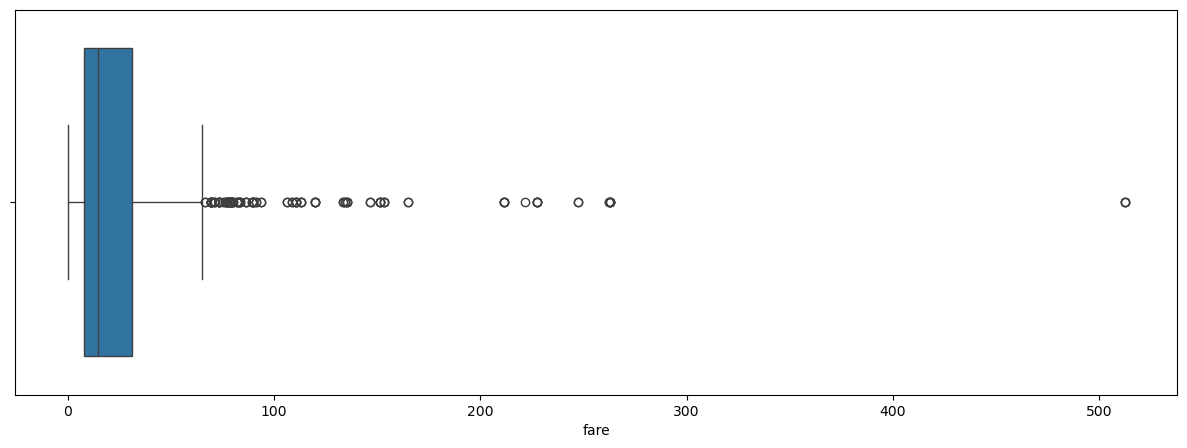

In [109]:
plt.figure(figsize = (15, 5))
sns.boxplot(x = df.fare)

## Outlier Romoving Using IQR

In [110]:
Q1 = df['fare'].quantile(0.25)
Q3 = df['fare'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(lower_bound)
print(upper_bound)

-26.724
65.6344


In [111]:
new_df = df[df['fare'] <= upper_bound]

<Axes: xlabel='fare'>

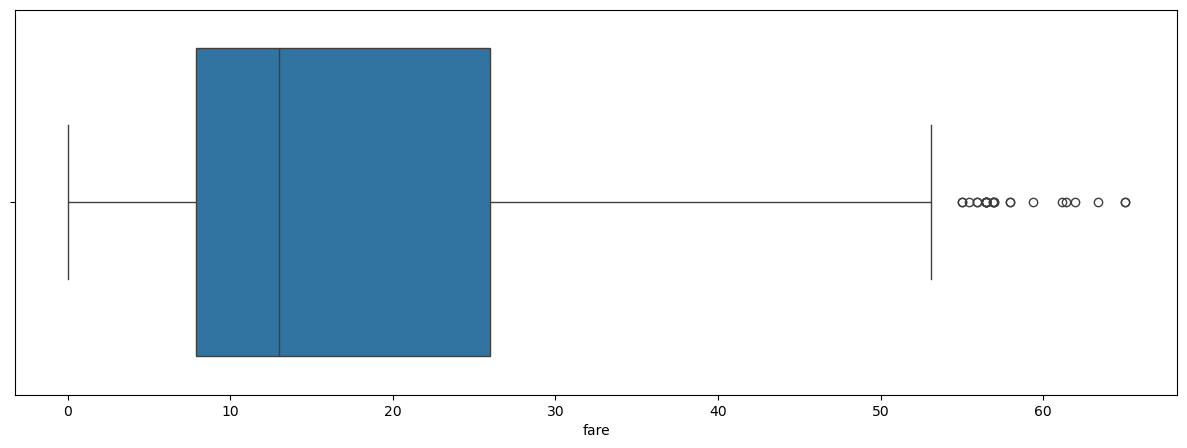

In [112]:
plt.figure(figsize = (15, 5))
sns.boxplot(x = new_df.fare)

## Outlier Removing Using Z-Score

In [113]:
df['fare'].isnull().sum()

np.int64(0)

In [114]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


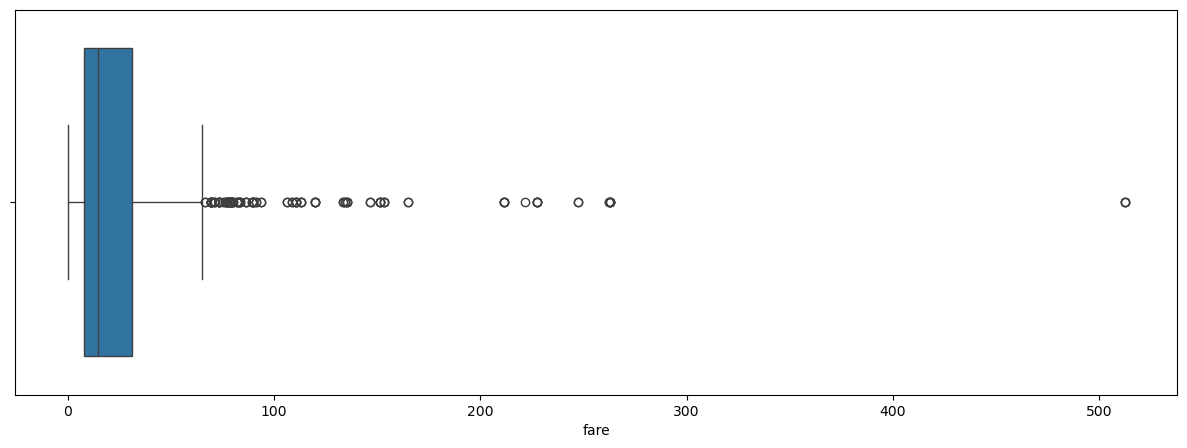

In [115]:
plt.figure(figsize = (15, 5))
sns.boxplot(x = df.fare)

plt.show()

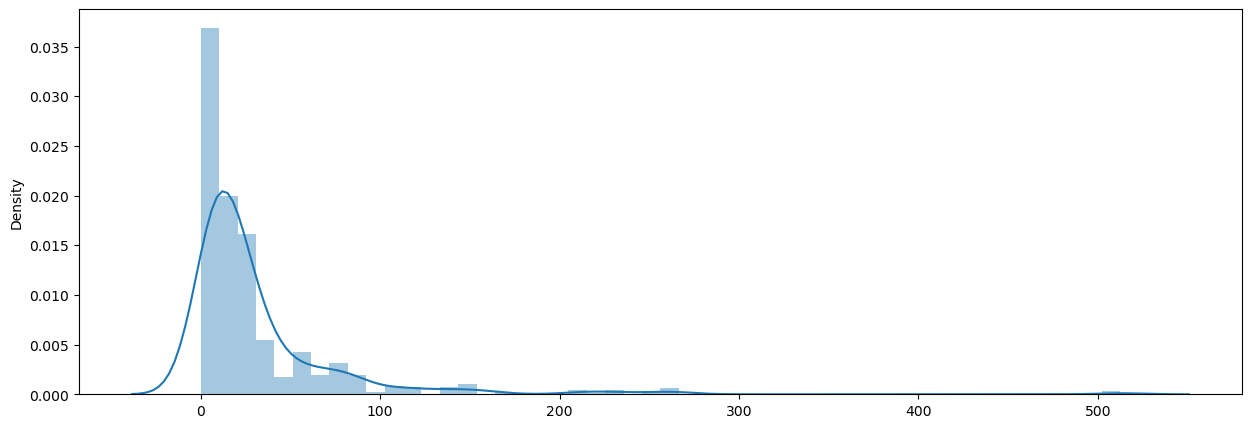

In [116]:
plt.figure(figsize = (15, 5))
ax = sns.distplot(x = df.fare)

plt.show()

In [117]:
min_range = df['fare'].mean() - (3 * df['fare'].std())
max_range = df['fare'].mean() + (3 * df['fare'].std())

print(min_range)
print(max_range)

-116.87607782296807
181.28449376011736


In [118]:
z_scr_df = df[df['fare'] <= max_range]

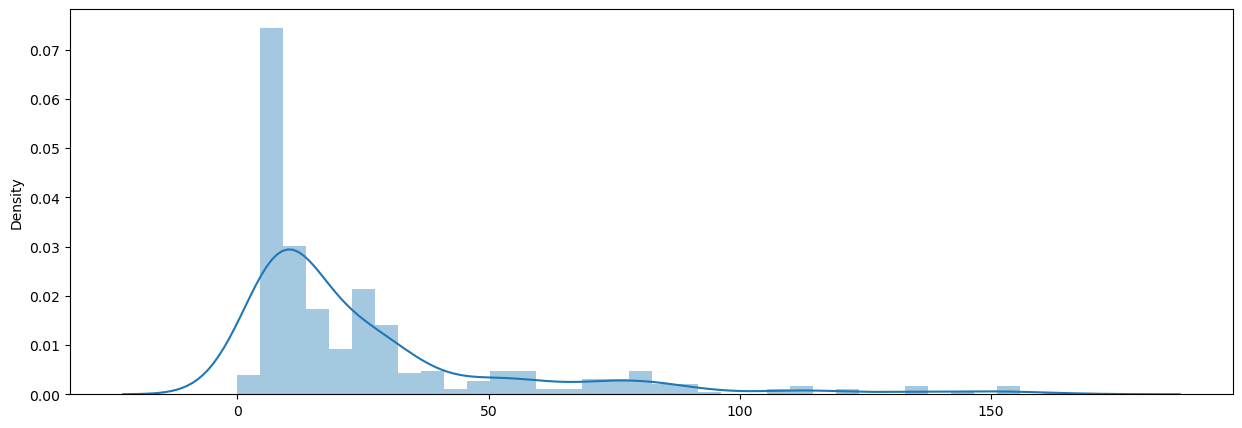

In [119]:
plt.figure(figsize = (15, 5))
ax = sns.distplot(x = z_scr_df.fare)

plt.show()

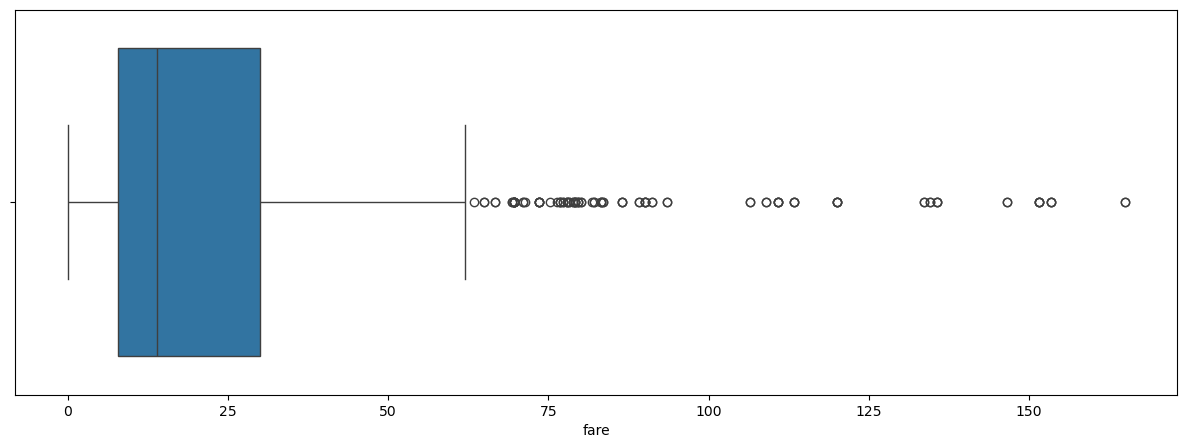

In [120]:
plt.figure(figsize = (15, 5))
ax = sns.boxplot(x = z_scr_df.fare)

plt.show()

In [121]:
z_score = (df['fare'] - df['fare'].mean())/(df['fare'].std())

In [122]:
df['z_score'] = z_score

In [123]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,z_score
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False,-0.502163
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False,0.786404
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True,-0.488580
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False,0.420494
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True,-0.486064


In [124]:
z_score_df = df[df['z_score'] < 3]

In [125]:
z_score_df.shape, z_scr_df.shape

((871, 16), (871, 15))

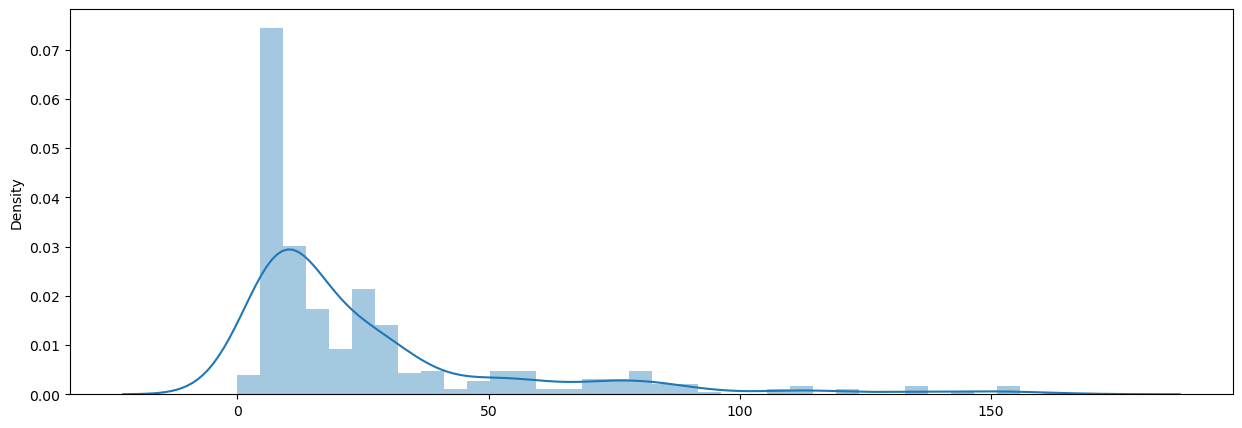

In [126]:
plt.figure(figsize = (15, 5))
ax = sns.distplot(x = z_score_df.fare)

plt.show()

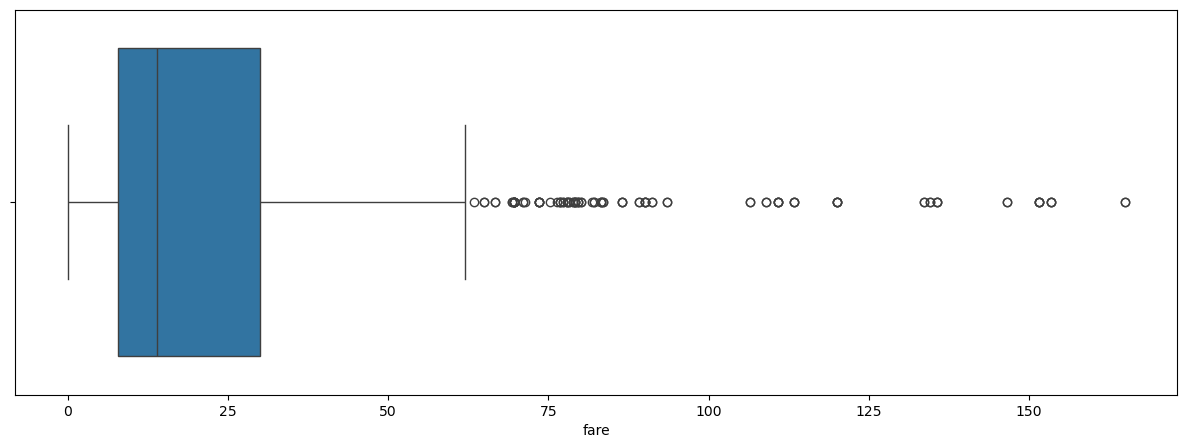

In [127]:
plt.figure(figsize = (15, 5))
ax = sns.boxplot(x = z_score_df.fare)

plt.show()